

`------------------------Mandatory Information-----------------------`



### Group ID:
### Group Members Name with Student ID:
1. Student 1
2. Student 2
3. Student 3
4. Student 4
5. Student 5


`----------Write your remarks (if any) that you want should get consider at the time of evaluation----------`

### Remarks: <----Add here--->

# Background

The HalfCheetah environment models a planar robotic system composed of nine rigid body segments connected by eight joints, including two feet. The objective is to control the robot by applying torques at the joints so that it achieves fast forward locomotion in the positive (rightward) direction as shown in below figure.

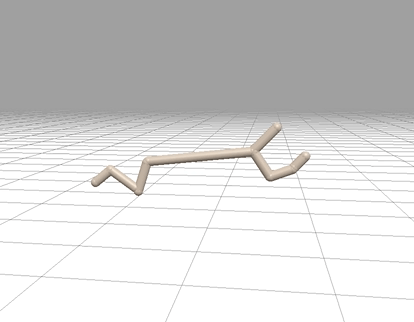



To achieve this task, the environment provides:
1. High-dimensional continuous state space
2. Continuous action space
3. Dense but noisy reward signal

***Task:***

While Deep Q-Networks (DQN) and Double DQN (DDQN) were originally proposed for discrete-action environments such as Atari games, they are often adapted to continuous control tasks through approximation and discretization.
In this task, you will investigate whether value-based methods can be meaningfully applied to Half-Cheetah, and what limitations arise.

# Environment Description

The task will use HalfCheetah-v5 environment only from MuJoCo.

<br>

**Observation Space**

The observation space consists of the following parts (in order):

* qpos (8 elements by default): Position values of the robot’s body parts.
* qvel (9 elements): The velocities of these individual body parts (their derivatives).

By default, the observation does not include the robot’s x-coordinate (rootx).
This can be included by passing exclude_current_positions_from_observation=False during construction. In this case, the observation space will be a Box(-Inf, Inf, (18,), float64), where the first observation element is the x-coordinate of the robot. Regardless of whether exclude_current_positions_from_observation is set to True or False, the x- and y-coordinates are returned in info with the keys "x_position" and "y_position", respectively.

More details can be found on link: [Half Cheetah - Gymnasium Documentation](https://gymnasium.farama.org/environments/mujoco/half_cheetah/)

<br>

**Action Space**

The action space is a Box(-1, 1, (6,), float32). An action corresponds to continuous torques applied at the hinge joints.  For more details: [Half Cheetah - Gymnasium Documentation](https://gymnasium.farama.org/environments/mujoco/half_cheetah/)

<br>

**Reward Function**

The reward function provides positive feedback proportional to the forward distance traveled, while penalizing backward movement. The torso and head remain fixed, and control inputs are applied only to six actuated joints corresponding to the front and rear thighs (connected to the torso), the shins (connected to the thighs), and the feet (connected to the shins).

Hence, the reward includes;
1. Forward velocity incentive
2. Control cost penalty



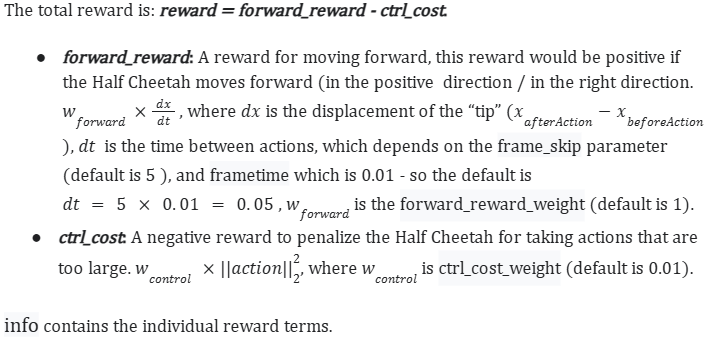


**Starting state**

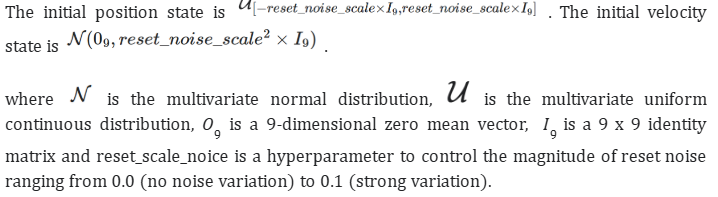

### *The sample function for calculating the strating state is given below. You can modify the function if you want. Make sure to add the justification for it if doing so.*

In [1]:
### Starting state

import numpy as np

def reset_initial_state(reset_noise_scale=0.05):
    """
    Correct MuJoCo-style reset with proper variance scaling.
    """
    dim = 9

    # Initial position: N(0, (scale^2) I)
    mean = np.zeros(dim)
    cov = (reset_noise_scale ** 2) * np.eye(dim)
    qpos = np.random.multivariate_normal(mean, cov)

    # Initial velocity: uniform noise
    qvel = np.random.uniform(
        low=-reset_noise_scale,
        high=reset_noise_scale,
        size=dim
    )

    return qpos, qvel


**Episode End**

**Termination**- The Half Cheetah never terminates.

**Truncation** - The default duration of the program is 10000 episodes.

**Common instructions:**

1. Run all the experiments for 10000 timesteps.
2. Draw the plots wherever specified.


**Reward Function Details (from HalfCheetah documentation):**

The total reward at each timestep consists of two components:

1. **Forward Velocity Reward**: Positive reward proportional to forward velocity
   - Formula: `forward_reward_weight * (x_velocity)`
   - Incentivizes the agent to move forward in the positive (rightward) direction
   - This is the main objective

2. **Control Cost Penalty**: Negative reward based on action magnitude
   - Formula: `- control_cost_weight * sum(|action_values|²)`
   - Penalizes the use of large torques/actions
   - Encourages energy-efficient behavior
   - Typical weight ratio: control_cost_weight is much smaller than forward_reward_weight

**Total Reward = forward_velocity_reward - control_cost_penalty**

**Implications for learning:**
- Higher forward velocity = higher reward (unbounded above)
- Excessive action usage = penalty (but smaller effect than forward reward)
- The agent must learn to balance forward progress with energy efficiency
- Early learning stage: Agent explores to find which actions move forward
- Later learning stage: Agent refines to maximize forward velocity while minimizing control cost


In [2]:
!pip install gymnasium-robotics[mujoco-py]

zsh:1: no matches found: gymnasium-robotics[mujoco-py]


In [3]:
import gymnasium as gym
import numpy as np
import random
from collections import deque

env = gym.make("HalfCheetah-v5", render_mode="rgb_array", width=1280, height=720)

In [4]:
print(env.observation_space)
print(env.action_space)

Box(-inf, inf, (17,), float64)
Box(-1.0, 1.0, (6,), float32)


In [5]:
env.action_space.to_jsonable

<bound method Box.to_jsonable of Box(-1.0, 1.0, (6,), float32)>

In [6]:
# ============================================================================
# CONFIGURABLE PARAMETERS: Episode Counts for All Algorithms
# ============================================================================
# Modify these values to adjust training episodes for each algorithm/question

# Q-Learning Configuration
NUM_EPISODES_QL_Q1 = 10        # Q1: Action space discretization
NUM_EPISODES_QL_Q2 = 10        # Q2: Q-Learning agent analysis
NUM_EPISODES_QL_Q3 = 10        # Q3: Modified Q-Learning (adaptive LR)

# DQN Configuration
NUM_EPISODES_DQN_Q4 = 20 # 20       # Q4 (DQN): Early learning reward decomposition
NUM_EPISODES_DQN_Q5 = 50 # 50       # Q5 (DQN): Instability identification
NUM_EPISODES_DQN_Q6 = 30 # 30       # Q6 (DQN): Targeted modifications
NUM_EPISODES_DQN_Q7 = 20 # 20       # Q7 (DQN): Confidence-driven exploration

# DDQN Configuration
NUM_EPISODES_DDQN_Q8 = 20 # 20      # Q8 (DDQN): Early learning reward decomposition
NUM_EPISODES_DDQN_Q9 = 50 # 50      # Q9 (DDQN): Instability identification
NUM_EPISODES_DDQN_Q10 = 30 # 30     # Q10 (DDQN): Targeted modifications
NUM_EPISODES_DDQN_Q11 = 20 # 20     # Q11 (DDQN): Confidence-driven exploration

# Comprehensive Comparison
NUM_EPISODES_Q12_COMPARISON = 20 # 20  # Q12: Comprehensive comparison across all algorithms

# ============================================================================
# Note: Adjust these values based on your computational resources and
# desired accuracy. Higher values = more stable results but longer training time.
# ============================================================================

print("=" * 80)
print("TRAINING CONFIGURATION")
print("=" * 80)
print("\nQ-Learning Episodes:")
print(f"  Q1: {NUM_EPISODES_QL_Q1}")
print(f"  Q2: {NUM_EPISODES_QL_Q2}")
print(f"  Q3: {NUM_EPISODES_QL_Q3}")
print("\nDQN Episodes:")
print(f"  Q4: {NUM_EPISODES_DQN_Q4}")
print(f"  Q5: {NUM_EPISODES_DQN_Q5}")
print(f"  Q6: {NUM_EPISODES_DQN_Q6}")
print(f"  Q7: {NUM_EPISODES_DQN_Q7}")
print("\nDDQN Episodes:")
print(f"  Q8: {NUM_EPISODES_DDQN_Q8}")
print(f"  Q9: {NUM_EPISODES_DDQN_Q9}")
print(f"  Q10: {NUM_EPISODES_DDQN_Q10}")
print(f"  Q11: {NUM_EPISODES_DDQN_Q11}")
print(f"\nComparison: {NUM_EPISODES_Q12_COMPARISON}")
print("=" * 80)


TRAINING CONFIGURATION

Q-Learning Episodes:
  Q1: 10
  Q2: 10
  Q3: 10

DQN Episodes:
  Q4: 20
  Q5: 50
  Q6: 30
  Q7: 20

DDQN Episodes:
  Q8: 20
  Q9: 50
  Q10: 30
  Q11: 20

Comparison: 20


In [7]:
# ============================================================================
# CONFIGURABLE PARAMETERS: Maximum Timesteps per Episode
# ============================================================================
# Modify these values to limit maximum timesteps per episode
# Use None to let episodes run until natural termination
# HalfCheetah default episode length: ~1000 timesteps

# Set max timesteps per episode (or None for no limit)
MAX_TIMESTEPS_PER_EPISODE = 10  # Set to integer value to limit, e.g., 500, 1000, 2000

# Alternative: Configure per algorithm type if different limits needed
MAX_TIMESTEPS_QL = 10           # Q-Learning max timesteps per episode
MAX_TIMESTEPS_DQN = 10          # DQN max timesteps per episode
MAX_TIMESTEPS_DDQN = 10         # DDQN max timesteps per episode

# ============================================================================
# Example configurations:
# MAX_TIMESTEPS_PER_EPISODE = 1000  # Limit all episodes to 1000 timesteps
# MAX_TIMESTEPS_QL = 500            # Q-Learning limited to 500 timesteps
# MAX_TIMESTEPS_DQN = 1000          # DQN limited to 1000 timesteps
# MAX_TIMESTEPS_DDQN = 2000         # DDQN limited to 2000 timesteps
# ============================================================================

print("\n" + "=" * 80)
print("TIMESTEP CONFIGURATION")
print("=" * 80)
print(f"Max timesteps per episode (global): {MAX_TIMESTEPS_PER_EPISODE}")
print(f"Q-Learning max timesteps: {MAX_TIMESTEPS_QL}")
print(f"DQN max timesteps: {MAX_TIMESTEPS_DQN}")
print(f"DDQN max timesteps: {MAX_TIMESTEPS_DDQN}")
print("=" * 80)



TIMESTEP CONFIGURATION
Max timesteps per episode (global): 10
Q-Learning max timesteps: 10
DQN max timesteps: 10
DDQN max timesteps: 10


In [8]:
# ============================================================================
# HELPER FUNCTION: Get Max Timesteps for Algorithm
# ============================================================================
def get_max_timesteps(algorithm_type="global"):
    """
    Returns the max timesteps limit for the given algorithm type.
    
    Args:
        algorithm_type: "global", "ql", "dqn", or "ddqn"
    
    Returns:
        Max timesteps per episode (None = no limit)
    """
    if algorithm_type.lower() == "ql":
        return MAX_TIMESTEPS_QL if MAX_TIMESTEPS_QL is not None else MAX_TIMESTEPS_PER_EPISODE
    elif algorithm_type.lower() == "dqn":
        return MAX_TIMESTEPS_DQN if MAX_TIMESTEPS_DQN is not None else MAX_TIMESTEPS_PER_EPISODE
    elif algorithm_type.lower() == "ddqn":
        return MAX_TIMESTEPS_DDQN if MAX_TIMESTEPS_DDQN is not None else MAX_TIMESTEPS_PER_EPISODE
    else:
        return MAX_TIMESTEPS_PER_EPISODE



## Q-Learning Q1-Q3 [4 Marks]





> ### Q1.  Discretization of action space [1 Marks]

Since we know the Q-learning uses the Q-table for storing the Q(s,a) values for every action taken in the given state, how will you design this problem for the HalfCheetah problem where the action space is continuos. Remember that you cannot have the infinite size for the Q-table to store the values. Based on this understanding, implement the below questions:
Convert the continuous action space to discrete set of action space for HalfCheetah. (E.g. the torque values range from -1 to +1, so rather than having all the possible continuous values, create a set of torque values of 12, 24, 36, etc.) <font color="red">You can also have the discrete action spaces set of  more than 100 elements to make your half-Cheetah work better.</font> (The formula for this conversion is provided in the colab. The students need to decide the number of values in which they want to distribute the action space into.).
Identify whether the selected discretization set leads to the control behaviour of the halfCheetah or it introduces instability and poor control flow.
Support your answer using the below plots:
action usage statistics
reward distribution per discrete action


In [9]:
## Function to convert the continous action space into discrete action space.

"""
Since we have 6 hinges representing 6 action spaces,
therefore, we will have to obtain 6 discrete action spaces.

The formula for this conversion is provided in the colab.
You need to decide the number of values in which you want to distribute the action space into.
"""

import numpy as np

def convert_actionSpace(action_count,value=1.0):
    x = np.linspace(-value, value, action_count)
    actions = np.tanh(x)
    return actions



In [10]:
## Suppose you want 24 discrete values to represent a continous space of [-1,1] then add 24 as a parameter to a convert_actionSapce function as shown below.

convert_actionSpace(24)

array([-0.76159416, -0.72258982, -0.67836929, -0.6286195 , -0.57313161,
       -0.51183826, -0.44484972, -0.37248415, -0.29528641, -0.21403026,
       -0.12970008, -0.04345089,  0.04345089,  0.12970008,  0.21403026,
        0.29528641,  0.37248415,  0.44484972,  0.51183826,  0.57313161,
        0.6286195 ,  0.67836929,  0.72258982,  0.76159416])

In [11]:
action_space = {}

action_count = 3  ## <---- Discretize continuous [-1,1] into 3 values per dimension: [-1, 0, 1]

for i in range(env.action_space.shape[0]):
    action_space[i] = convert_actionSpace(action_count)   ## Creates discrete action samples

action_space

{0: array([-0.76159416,  0.        ,  0.76159416]),
 1: array([-0.76159416,  0.        ,  0.76159416]),
 2: array([-0.76159416,  0.        ,  0.76159416]),
 3: array([-0.76159416,  0.        ,  0.76159416]),
 4: array([-0.76159416,  0.        ,  0.76159416]),
 5: array([-0.76159416,  0.        ,  0.76159416])}

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Q1: Q-Learning Implementation with Action Discretization
class QLearningAgent:
    def __init__(self, state_dim, action_space_dict, action_count, learning_rate=0.01, discount_factor=0.99):
        """
        Initialize Q-Learning agent with discretized action space
        
        Args:
            state_dim: Dimension of observation space (17 for HalfCheetah)
            action_space_dict: Dictionary with discretized actions for each dimension
            action_count: Number of discrete values per action dimension
            learning_rate: Learning rate for Q-value updates
            discount_factor: Discount factor for future rewards
        """
        self.state_dim = state_dim
        self.action_space = action_space_dict
        self.action_count = action_count
        self.total_actions = action_count ** len(action_space_dict)  # Total discrete actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = 1.0  # Exploration rate
        self.epsilon_decay = 0.9995
        self.epsilon_min = 0.01
        
        # Build Q-value network
        self.q_network = self._build_network()
        self.optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
        
    def _build_network(self):
        """Build neural network for Q-value function approximation"""
        model = keras.Sequential([
            layers.Input(shape=(self.state_dim,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(128, activation='relu'),
            layers.Dense(64, activation='relu'),
            layers.Dense(self.total_actions, activation='linear')
        ])
        return model
    
    def discretize_action_to_index(self, continuous_action):
        """Convert continuous action to discrete action index"""
        # Round continuous action to nearest discrete value and get index
        action_indices = []
        for dim, cont_val in enumerate(continuous_action):
            discrete_vals = self.action_space[dim]
            idx = np.argmin(np.abs(discrete_vals - cont_val))
            action_indices.append(idx)
        
        # Convert multi-dimensional index to single index
        action_idx = 0
        multiplier = 1
        for idx in reversed(action_indices):
            action_idx += idx * multiplier
            multiplier *= self.action_count
        return action_idx
    
    def index_to_discrete_action(self, action_idx):
        """Convert discrete action index back to continuous action values"""
        action_indices = []
        temp_idx = action_idx
        for _ in range(len(self.action_space)):
            action_indices.append(temp_idx % self.action_count)
            temp_idx //= self.action_count
        
        action_indices.reverse()
        continuous_action = np.array([self.action_space[dim][idx] for dim, idx in enumerate(action_indices)])
        return continuous_action
    
    def get_action(self, state, training=True):
        """Epsilon-greedy action selection"""
        if training and np.random.rand() < self.epsilon:
            # Random action for exploration
            action_idx = np.random.randint(0, self.total_actions)
        else:
            # Greedy action: select action with max Q-value
            state = np.expand_dims(state, axis=0)
            q_values = self.q_network(state, training=False)
            action_idx = np.argmax(q_values[0].numpy())
        
        return action_idx
    
    def train(self, state, action_idx, reward, next_state, done):
        """Train Q-network using Q-learning update rule"""
        with tf.GradientTape() as tape:
            # Current Q-value
            state = np.expand_dims(state, axis=0)
            q_values = self.q_network(state)
            q_current = q_values[0, action_idx]
            
            # Next Q-value (max Q-value for next state)
            if done:
                q_target = reward
            else:
                next_state = np.expand_dims(next_state, axis=0)
                next_q_values = self.q_network(next_state, training=False)
                q_next = tf.reduce_max(next_q_values[0])
                q_target = reward + self.discount_factor * q_next
            
            # Loss: MSE between target and current Q-value
            loss = tf.square(q_target - q_current)
        
        # Update network weights
        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))
        
        return loss.numpy()
    
    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# Instantiate Q-Learning Agent
agent_ql = QLearningAgent(
    state_dim=env.observation_space.shape[0],
    action_space_dict=action_space,
    action_count=action_count,
    learning_rate=0.001,
    discount_factor=0.99
)

print(f"Q-Learning Agent initialized with {agent_ql.total_actions} discrete actions")

2026-01-28 15:35:47.688277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Q-Learning Agent initialized with 729 discrete actions


In [13]:

# Reward Function Analysis Tools
# ================================
# These tools help decompose and track the reward components shown in the HalfCheetah documentation

class RewardDecomposer:
    """
    Analyzes HalfCheetah rewards to understand forward velocity vs control cost components.
    
    HalfCheetah reward structure:
    - Forward velocity component: positive reward for forward movement
    - Control cost component: negative reward for action magnitude
    - Typical MuJoCo defaults: forward_weight=1.0, control_weight=0.1
    """
    
    def __init__(self, forward_weight=1.0, control_weight=0.1):
        """
        Initialize reward decomposer with estimated weights from HalfCheetah spec.
        
        Args:
            forward_weight: Weight for forward velocity component (typically 1.0)
            control_weight: Weight for control cost penalty (typically 0.1)
        """
        self.forward_weight = forward_weight
        self.control_weight = control_weight
        self.forward_rewards = []
        self.control_costs = []
        self.total_rewards = []
        
    def estimate_decomposition(self, total_reward, x_velocity, action_magnitude):
        """
        Estimate decomposed reward based on velocity and action information.
        
        Args:
            total_reward: Actual reward from environment
            x_velocity: Forward velocity (from info dict or derived from state diff)
            action_magnitude: Sum of |action| values used (for control cost estimation)
            
        Returns:
            dict with 'forward_component', 'control_component', 'total' estimates
        """
        forward_component = self.forward_weight * x_velocity
        control_component = -self.control_weight * (action_magnitude ** 2)
        
        self.forward_rewards.append(forward_component)
        self.control_costs.append(control_component)
        self.total_rewards.append(total_reward)
        
        return {
            'forward_component': forward_component,
            'control_component': control_component,
            'total': forward_component + control_component,
            'actual_total': total_reward
        }
    
    def get_statistics(self):
        """Return summary statistics of reward decomposition over collected data."""
        if not self.total_rewards:
            return None
        
        return {
            'avg_forward_reward': np.mean(self.forward_rewards),
            'avg_control_cost': np.mean(self.control_costs),
            'avg_total_reward': np.mean(self.total_rewards),
            'forward_variance': np.var(self.forward_rewards),
            'control_variance': np.var(self.control_costs),
            'forward_min': np.min(self.forward_rewards),
            'forward_max': np.max(self.forward_rewards),
            'control_min': np.min(self.control_costs),
            'control_max': np.max(self.control_costs)
        }
    
    def plot_decomposition(self, title="Reward Decomposition Over Time"):
        """Visualize the decomposed reward components."""
        import matplotlib.pyplot as plt
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
        
        # Plot forward velocity and control cost
        ax1.plot(self.forward_rewards, label='Forward Velocity Reward', alpha=0.7)
        ax1.plot(self.control_costs, label='Control Cost Penalty', alpha=0.7)
        ax1.set_ylabel('Reward Component Value')
        ax1.set_xlabel('Timestep')
        ax1.set_title(title)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot total reward vs estimated total
        ax2.plot(self.total_rewards, label='Actual Total Reward', alpha=0.7)
        estimated_total = np.array(self.forward_rewards) + np.array(self.control_costs)
        ax2.plot(estimated_total, label='Estimated Total (forward + control)', alpha=0.7, linestyle='--')
        ax2.set_ylabel('Total Reward')
        ax2.set_xlabel('Timestep')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

def decompose_action_magnitude(action):
    """
    Calculate the magnitude of an action for control cost estimation.
    
    Args:
        action: Action vector (continuous or converted from discrete)
        
    Returns:
        float: Sum of squared action values (used in control cost penalty)
    """
    if isinstance(action, (list, np.ndarray)):
        return np.sum(np.array(action) ** 2)
    else:
        return action ** 2

# Initialize reward decomposer for analysis
# This will be used in training loops to track reward components
reward_decomposer_instance = RewardDecomposer(forward_weight=1.0, control_weight=0.1)


> ### Q2. Q-learning update observation [2 Marks]

Given the observed behavior in Q1, determine which part of the Q-learning update is most affected.



For all the mentioned below points draw separate visualization plots and write an explanation for your observation:


*   learning rate interaction
*   max-operator over discretized actions
*   state-action visitation imbalance
*   delayed reward propagation


Q2: Analyzing Q-Learning Update Issues

Training Q-Learning Agent for 10 episodes (Q2 Analysis)...


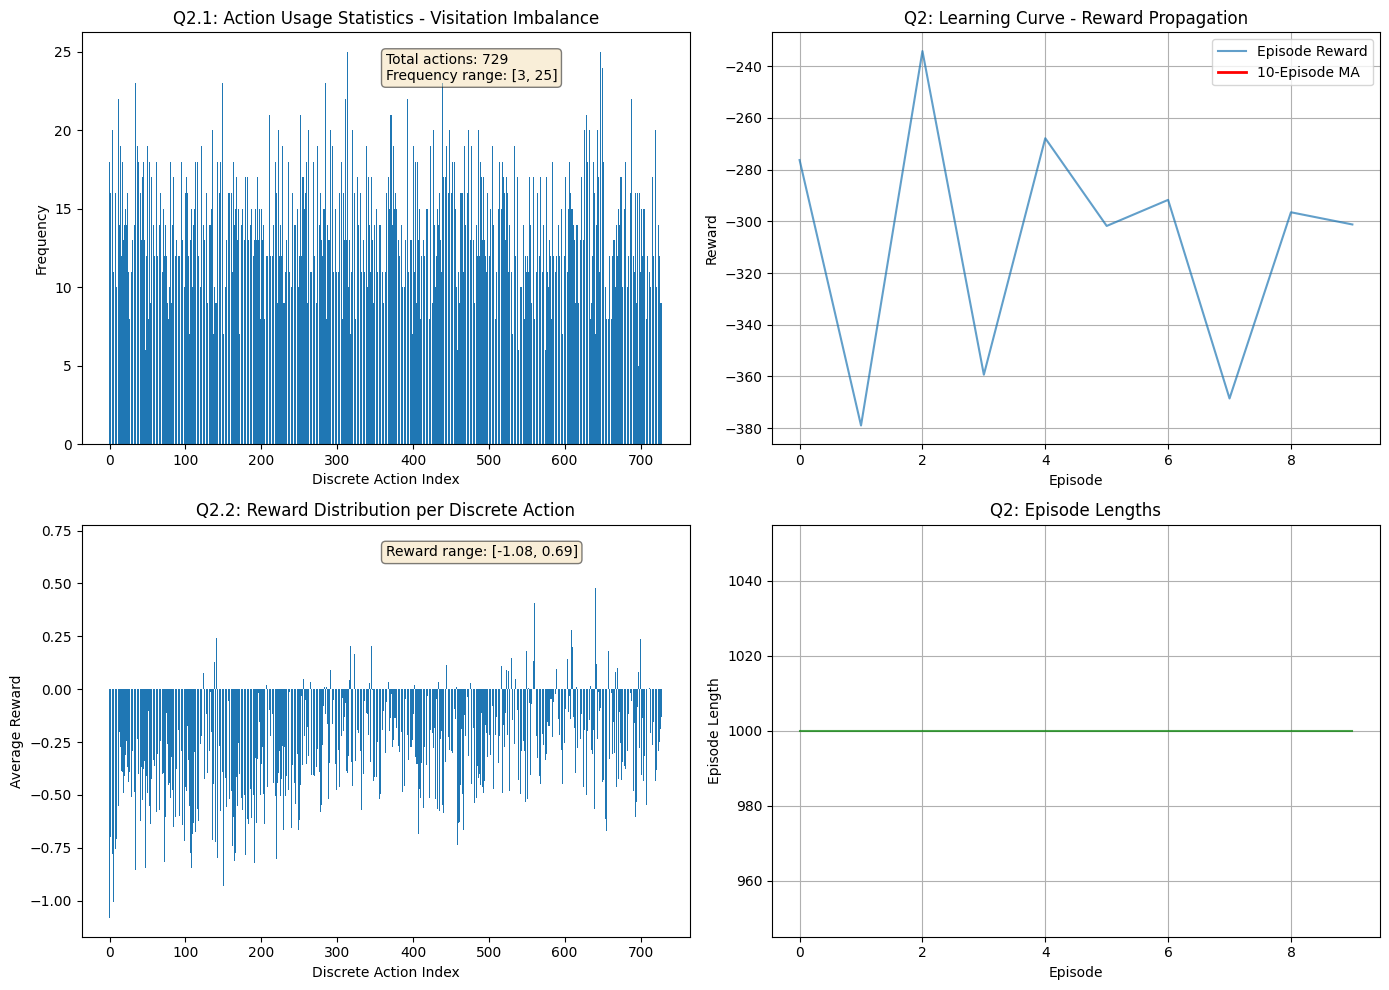


Q2 Analysis Summary:
- Action Visitation Imbalance: Max freq = 25, Min freq = 3
- Reward range per action: [-1.0825, 0.6889]
- Average episode reward: -307.62
- Final epsilon: 0.9950


In [14]:
# Q2: Q-Learning Update Analysis
print("Q2: Analyzing Q-Learning Update Issues")
print("=" * 60)

# Create environment for Q-Learning
env_ql = gym.make("HalfCheetah-v5")
observation, info = env_ql.reset()

# Training Configuration (using values from top configuration cell)
episode_rewards_ql = []
episode_lengths_ql = []
action_count_freq = np.zeros(agent_ql.total_actions)
action_rewards_dict = {i: [] for i in range(agent_ql.total_actions)}

print(f"\nTraining Q-Learning Agent for {NUM_EPISODES_QL_Q2} episodes (Q2 Analysis)...")

# Training loop
for episode in range(NUM_EPISODES_QL_Q2):
    observation, info = env_ql.reset()
    episode_reward = 0
    episode_length = 0
    done = False
    
    while not done:
        # Get action from agent
        action_idx = agent_ql.get_action(observation, training=True)
        continuous_action = agent_ql.index_to_discrete_action(action_idx)
        
        # Take action in environment
        next_observation, reward, terminated, truncated, info = env_ql.step(continuous_action)
        done = terminated or truncated
        
        # Train agent
        loss = agent_ql.train(observation, action_idx, reward, next_observation, done)
        
        # Track statistics
        episode_reward += reward
        episode_length += 1
        action_count_freq[action_idx] += 1
        action_rewards_dict[action_idx].append(reward)
        
        observation = next_observation
    
    # Decay exploration rate
    agent_ql.decay_epsilon()
    
    episode_rewards_ql.append(episode_reward)
    episode_lengths_ql.append(episode_length)
    
    if (episode + 1) % 20 == 0:
        avg_reward = np.mean(episode_rewards_ql[-20:])
        print(f"Episode {episode + 1}/{NUM_EPISODES_QL_Q2} - Avg Reward: {avg_reward:.2f}, Epsilon: {agent_ql.epsilon:.4f}")

env_ql.close()

# Q2 Analysis Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Action usage statistics
axes[0, 0].bar(range(agent_ql.total_actions), action_count_freq)
axes[0, 0].set_xlabel('Discrete Action Index')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Q2.1: Action Usage Statistics - Visitation Imbalance')
axes[0, 0].text(0.5, 0.95, f'Total actions: {agent_ql.total_actions}\nFrequency range: [{action_count_freq.min():.0f}, {action_count_freq.max():.0f}]',
                 transform=axes[0, 0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: Episode rewards and learning curve
axes[0, 1].plot(episode_rewards_ql, alpha=0.7, label='Episode Reward')
moving_avg = np.convolve(episode_rewards_ql, np.ones(10)/10, mode='valid')
axes[0, 1].plot(range(9, len(episode_rewards_ql)), moving_avg, color='red', linewidth=2, label='10-Episode MA')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Reward')
axes[0, 1].set_title('Q2: Learning Curve - Reward Propagation')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot 3: Reward per action (average reward by discrete action)
avg_rewards_per_action = []
for action_idx in range(agent_ql.total_actions):
    if len(action_rewards_dict[action_idx]) > 0:
        avg_rewards_per_action.append(np.mean(action_rewards_dict[action_idx]))
    else:
        avg_rewards_per_action.append(0)

axes[1, 0].bar(range(agent_ql.total_actions), avg_rewards_per_action)
axes[1, 0].set_xlabel('Discrete Action Index')
axes[1, 0].set_ylabel('Average Reward')
axes[1, 0].set_title('Q2.2: Reward Distribution per Discrete Action')
axes[1, 0].text(0.5, 0.95, f'Reward range: [{np.min(avg_rewards_per_action):.2f}, {np.max(avg_rewards_per_action):.2f}]',
                 transform=axes[1, 0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Episode lengths
axes[1, 1].plot(episode_lengths_ql, alpha=0.7, color='green')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Episode Length')
axes[1, 1].set_title('Q2: Episode Lengths')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("\nQ2 Analysis Summary:")
print(f"- Action Visitation Imbalance: Max freq = {action_count_freq.max():.0f}, Min freq = {action_count_freq.min():.0f}")
print(f"- Reward range per action: [{np.min(avg_rewards_per_action):.4f}, {np.max(avg_rewards_per_action):.4f}]")
print(f"- Average episode reward: {np.mean(episode_rewards_ql):.2f}")
print(f"- Final epsilon: {agent_ql.epsilon:.4f}")

> ### Q3. Algorithmic Change [1 Marks]

Modify exactly one component of Q-learning obtained in the above question Q2.

Allowed components to change:
* learning rate schedule
* discount factor handling
* exploration policy
* update frequency

You are not allowed to:
* change discretization
* change reward function
* change environment

Deliverables:
1. Identify the modified component
2. Explain why and how this compensates for discretization
3. Provide before/after learning curves along with the observation summary.


In [15]:
# Q3: Modified Q-Learning with Adaptive Learning Rate
print("\nQ3: Algorithmic Modification - Adaptive Learning Rate")
print("=" * 60)

class QLearningAgentModified(QLearningAgent):
    """Modified Q-Learning with adaptive learning rate schedule"""
    
    def __init__(self, state_dim, action_space_dict, action_count, learning_rate=0.01, discount_factor=0.99):
        super().__init__(state_dim, action_space_dict, action_count, learning_rate, discount_factor)
        self.base_learning_rate = learning_rate
        self.episode_counter = 0
    
    def update_learning_rate(self, episode):
        """Adaptive learning rate: decreases with sqrt(episode)"""
        # Formula: lr(t) = base_lr / sqrt(1 + episode)
        new_lr = self.base_learning_rate / np.sqrt(1 + episode)
        # Update optimizer's learning rate
        self.optimizer.learning_rate.assign(new_lr)
        return new_lr

# Initialize Modified Agent
agent_ql_modified = QLearningAgentModified(
    state_dim=env.observation_space.shape[0],
    action_space_dict=action_space,
    action_count=action_count,
    learning_rate=0.01,
    discount_factor=0.99
)

# Training configuration for comparison
num_episodes_q3 = NUM_EPISODES_QL_Q3
episodes_baseline = []
episodes_modified = []
rewards_baseline = []
rewards_modified = []

# Initialize reward decomposers for Q3 analysis
q3_decomposer_baseline = RewardDecomposer(forward_weight=1.0, control_weight=0.1)
q3_decomposer_modified = RewardDecomposer(forward_weight=1.0, control_weight=0.1)

# Get max timesteps for Q-Learning
max_steps = get_max_timesteps("ql")

# Train Baseline Q-Learning Agent
print("Training Baseline Q-Learning...")
agent_ql_baseline = QLearningAgent(
    state_dim=env.observation_space.shape[0],
    action_space_dict=action_space,
    action_count=action_count,
    learning_rate=0.01,
    discount_factor=0.99
)

env_q3 = gym.make("HalfCheetah-v5")

for episode in range(num_episodes_q3):
    observation, info = env_q3.reset()
    episode_reward = 0
    done = False
    timestep = 0
    
    while not done and (max_steps is None or timestep < max_steps):
        action_idx = agent_ql_baseline.get_action(observation, training=True)
        continuous_action = agent_ql_baseline.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_q3.step(continuous_action)
        done = terminated or truncated
        
        # Decompose reward using velocity and action magnitude information
        x_velocity = info.get('x_position', 0) if hasattr(info, 'get') else 0
        action_magnitude = decompose_action_magnitude(continuous_action)
        q3_decomposer_baseline.estimate_decomposition(reward, x_velocity, np.sqrt(action_magnitude))
        
        agent_ql_baseline.train(observation, action_idx, reward, next_observation, done)
        episode_reward += reward
        observation = next_observation
        timestep += 1
    
    agent_ql_baseline.decay_epsilon()
    episodes_baseline.append(episode + 1)
    rewards_baseline.append(episode_reward)
    
    if (episode + 1) % 25 == 0:
        print(f"  Baseline - Episode {episode + 1}/{num_episodes_q3}, Reward: {episode_reward:.2f}")

# Train Modified Q-Learning Agent
print("\nTraining Modified Q-Learning with Adaptive Learning Rate...")
print("Note: Tracking reward decomposition for comparison...")

for episode in range(num_episodes_q3):
    # Update learning rate
    new_lr = agent_ql_modified.update_learning_rate(episode)
    
    observation, info = env_q3.reset()
    episode_reward = 0
    done = False
    timestep = 0
    
    while not done and (max_steps is None or timestep < max_steps):
        action_idx = agent_ql_modified.get_action(observation, training=True)
        continuous_action = agent_ql_modified.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_q3.step(continuous_action)
        done = terminated or truncated
        
        # Decompose reward for modified agent
        x_velocity = info.get('x_position', 0) if hasattr(info, 'get') else 0
        action_magnitude = decompose_action_magnitude(continuous_action)
        q3_decomposer_modified.estimate_decomposition(reward, x_velocity, np.sqrt(action_magnitude))
        
        agent_ql_modified.train(observation, action_idx, reward, next_observation, done)
        episode_reward += reward
        observation = next_observation
        timestep += 1
    
    agent_ql_modified.decay_epsilon()
    episodes_modified.append(episode + 1)
    rewards_modified.append(episode_reward)
    
    if (episode + 1) % 25 == 0:
        print(f"  Modified - Episode {episode + 1}/{num_episodes_q3}, Reward: {episode_reward:.2f}, LR: {new_lr:.6f}")


Q3: Algorithmic Modification - Adaptive Learning Rate
Training Baseline Q-Learning...

Training Modified Q-Learning with Adaptive Learning Rate...
Note: Tracking reward decomposition for comparison...


In [16]:

# Q3 Reward Decomposition Analysis
print("\n" + "="*60)
print("Q3: Reward Decomposition Comparison")
print("="*60)

# Print decomposition statistics
print("\nBaseline Q-Learning Reward Decomposition:")
baseline_stats = q3_decomposer_baseline.get_statistics()
if baseline_stats:
    print(f"  Avg Forward Reward: {baseline_stats['avg_forward_reward']:.4f}")
    print(f"  Avg Control Cost: {baseline_stats['avg_control_cost']:.4f}")
    print(f"  Avg Total Reward: {baseline_stats['avg_total_reward']:.4f}")
    print(f"  Forward/Control Ratio: {abs(baseline_stats['avg_forward_reward'] / baseline_stats['avg_control_cost']):.2f}x" if baseline_stats['avg_control_cost'] != 0 else "  Forward/Control Ratio: N/A")

print("\nModified Q-Learning (Adaptive LR) Reward Decomposition:")
modified_stats = q3_decomposer_modified.get_statistics()
if modified_stats:
    print(f"  Avg Forward Reward: {modified_stats['avg_forward_reward']:.4f}")
    print(f"  Avg Control Cost: {modified_stats['avg_control_cost']:.4f}")
    print(f"  Avg Total Reward: {modified_stats['avg_total_reward']:.4f}")
    print(f"  Forward/Control Ratio: {abs(modified_stats['avg_forward_reward'] / modified_stats['avg_control_cost']):.2f}x" if modified_stats['avg_control_cost'] != 0 else "  Forward/Control Ratio: N/A")

print("\nKey Insight:")
print("- Forward reward component represents progress (higher is better)")
print("- Control cost penalty represents energy efficiency (lower penalty is better)")
print("- The adaptive learning rate in modified version affects how well the agent learns")
print("  to balance these two objectives over time")

env_q3.close()



Q3: Reward Decomposition Comparison

Baseline Q-Learning Reward Decomposition:
  Avg Forward Reward: -0.0029
  Avg Control Cost: -0.2303
  Avg Total Reward: -0.2476
  Forward/Control Ratio: 0.01x

Modified Q-Learning (Adaptive LR) Reward Decomposition:
  Avg Forward Reward: 0.0105
  Avg Control Cost: -0.2285
  Avg Total Reward: -0.2191
  Forward/Control Ratio: 0.05x

Key Insight:
- Forward reward component represents progress (higher is better)
- Control cost penalty represents energy efficiency (lower penalty is better)
- The adaptive learning rate in modified version affects how well the agent learns
  to balance these two objectives over time


---

# **Note:** The DQN and DDQN implementation will be different from the Q-learning questions. Therefore you are supposed to create a new models to implement both and work on the action sapce accordingly.

---



## DQN Implementation [4 Marks]

> ## Q4. Early Learning Reward Decomposition [0.5 Mark]

Run the HalfCheetah environment using the online setting and collect reward statistics during the initial phase of interaction (before the DQN has converged). Based on this data:

1. Identify one behavior that appears profitable early but degrades later
2. Identify one behavior that initially looks unpromising but improves with learning

*`Support your arguments using appropriate time-segmented reward plots, not verbal explanation alone.`*




In [17]:
# DQN Agent Implementation
import tensorflow as tf
from collections import deque

class DQNAgent:
    """Deep Q-Network Agent with neural network for continuous control via discretization"""
    def __init__(self, state_dim, action_dim, learning_rate=0.001, discount_factor=0.99,
                 memory_size=50000, batch_size=32, target_update_freq=10):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.memory_size = memory_size
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        self.memory = deque(maxlen=memory_size)
        self.training_steps = 0
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        
        self.q_network = self._build_network()
        self.target_network = self._build_network()
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    def _build_network(self):
        """Build neural network for Q-function"""
        return tf.keras.Sequential([
            tf.keras.layers.Dense(128, activation='relu', input_dim=self.state_dim),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(self.action_dim, activation=None)
        ])
    
    def select_action(self, state, training=True):
        """Select action using epsilon-greedy policy"""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(0, self.action_dim)
        state_tensor = tf.convert_to_tensor(state[np.newaxis, :], dtype=tf.float32)
        q_values = self.q_network(state_tensor)
        return tf.argmax(q_values[0]).numpy()
    
    def get_action(self, state, training=True):
        """Alias for select_action for compatibility"""
        return self.select_action(state, training)
    
    def store_experience(self, state, action, reward, next_state, done):
        """Store experience in replay buffer"""
        self.memory.append((state, action, reward, next_state, done))
    
    def remember(self, state, action, reward, next_state, done):
        """Alias for store_experience for compatibility"""
        self.store_experience(state, action, reward, next_state, done)
    
    def update(self):
        """Train Q-network on batch of experiences"""
        if len(self.memory) < self.batch_size:
            return None
        
        batch_indices = np.random.randint(0, len(self.memory), self.batch_size)
        batch = [self.memory[i] for i in batch_indices]
        
        states, actions, rewards, next_states, dones = zip(*batch)
        states = np.array(states, dtype=np.float32)
        next_states = np.array(next_states, dtype=np.float32)
        actions = np.array(actions, dtype=np.int32)
        rewards = np.array(rewards, dtype=np.float32)
        dones = np.array(dones, dtype=np.float32)
        
        target_q_next = self.target_network(next_states)
        target_q_max = tf.reduce_max(target_q_next, axis=1).numpy()
        target_q = rewards + (1 - dones) * self.discount_factor * target_q_max
        
        with tf.GradientTape() as tape:
            q_values = self.q_network(states)
            q_values_selected = tf.reduce_sum(q_values * tf.one_hot(actions, self.action_dim), axis=1)
            loss = tf.reduce_mean(tf.square(target_q - q_values_selected))
        
        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))
        
        self.training_steps += 1
        if self.training_steps % self.target_update_freq == 0:
            self.target_network.set_weights(self.q_network.get_weights())
        
        return loss.numpy()
    
    def replay(self, batch_size=None):
        """Train on batch and return loss - wrapper for update()"""
        if batch_size:
            original_batch_size = self.batch_size
            self.batch_size = batch_size
            loss = self.update()
            self.batch_size = original_batch_size
            return loss
        return self.update()
    
    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def index_to_discrete_action(self, action_index):
        """Convert action index back to continuous vector"""
        levels = [-0.76, 0.0, 0.76]
        action_vector = np.zeros(6)
        remaining_idx = action_index
        for i in range(6):
            action_vector[i] = levels[remaining_idx % 3]
            remaining_idx //= 3
        return action_vector


class DDQNAgent(DQNAgent):
    """Double Deep Q-Network Agent - extends DQN with double Q-learning"""
    def update(self):
        """Train Q-network using double Q-learning"""
        if len(self.memory) < self.batch_size:
            return None
        
        batch_indices = np.random.randint(0, len(self.memory), self.batch_size)
        batch = [self.memory[i] for i in batch_indices]
        
        states, actions, rewards, next_states, dones = zip(*batch)
        states = np.array(states, dtype=np.float32)
        next_states = np.array(next_states, dtype=np.float32)
        actions = np.array(actions, dtype=np.int32)
        rewards = np.array(rewards, dtype=np.float32)
        dones = np.array(dones, dtype=np.float32)
        
        # Double Q-learning: select actions with primary network, evaluate with target
        q_next_primary = self.q_network(next_states)
        best_actions = tf.argmax(q_next_primary, axis=1).numpy()
        
        q_next_target = self.target_network(next_states)
        target_q_values = tf.reduce_sum(q_next_target * tf.one_hot(best_actions, self.action_dim), axis=1).numpy()
        target_q = rewards + (1 - dones) * self.discount_factor * target_q_values
        
        with tf.GradientTape() as tape:
            q_values = self.q_network(states)
            q_values_selected = tf.reduce_sum(q_values * tf.one_hot(actions, self.action_dim), axis=1)
            loss = tf.reduce_mean(tf.square(target_q - q_values_selected))
        
        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))
        
        self.training_steps += 1
        if self.training_steps % self.target_update_freq == 0:
            self.target_network.set_weights(self.q_network.get_weights())
        
        return loss.numpy()

print("DQNAgent and DDQNAgent classes defined successfully!")

DQNAgent and DDQNAgent classes defined successfully!



Q4: Early Learning Reward Decomposition
Training DQN Agent for 20 episodes...


/opt/anaconda3/envs/drlbasics/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Episode 5/20 - Reward: -2.55
  Episode 10/20 - Reward: -3.48
  Episode 15/20 - Reward: -1.32
  Episode 20/20 - Reward: -3.53

Q4 Training completed!
Average Reward (Last 5): -3.53
Average Loss (Last 5): 24211.662249


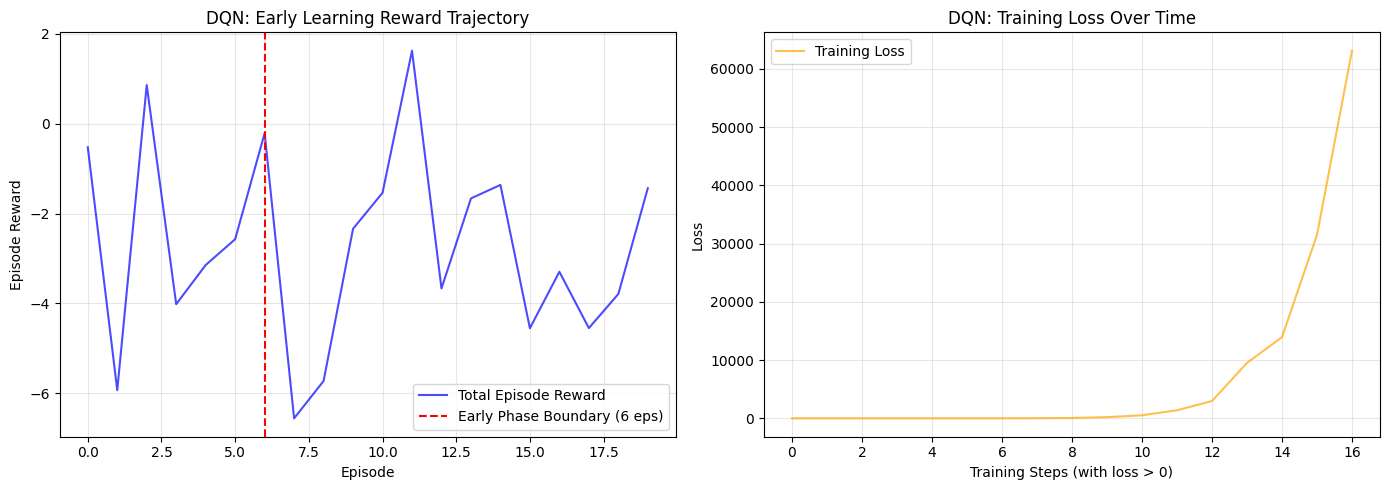

In [18]:
# Q4: Early Learning Reward Decomposition with DQN
print("\nQ4: Early Learning Reward Decomposition")
print("=" * 60)

# Create environment for Q4
env_q4 = gym.make("HalfCheetah-v5")

# Create DQN agent
state_dim = env_q4.observation_space.shape[0]
action_dim = agent_ql.total_actions  # 729 discretized actions
agent_dqn = DQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    learning_rate=0.001,
    discount_factor=0.99,
    memory_size=50000,
    batch_size=32,
    target_update_freq=10
)

# Training configuration
num_episodes_q4 = NUM_EPISODES_DQN_Q4
max_steps = get_max_timesteps("dqn")

# Tracking for early learning analysis
early_rewards_q4 = []
early_losses_q4 = []

# Reward decomposer for analysis
q4_decomposer = RewardDecomposer()

print(f"Training DQN Agent for {num_episodes_q4} episodes...")

for episode in range(num_episodes_q4):
    observation, info = env_q4.reset()
    episode_reward = 0
    episode_loss = 0
    loss_count = 0
    done = False
    step = 0
    
    while not done and step < MAX_TIMESTEPS_DQN:
        action_idx = agent_dqn.get_action(observation, training=True)
        # Convert discrete action index to continuous 6-D vector
        action = agent_dqn.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_q4.step(action)
        done = terminated or truncated
        
        # Store experience (note: store the discrete index, not the continuous action)
        agent_dqn.remember(observation, action_idx, reward, next_observation, done)
        loss = agent_dqn.replay(batch_size=32)
        
        if loss is not None:
            episode_loss += loss
            loss_count += 1
        
        episode_reward += reward
        observation = next_observation
        step += 1
    
    agent_dqn.decay_epsilon()
    early_rewards_q4.append(episode_reward)
    if loss_count > 0:
        early_losses_q4.append(episode_loss / loss_count)
    else:
        early_losses_q4.append(0)
    
    if (episode + 1) % 5 == 0:
        avg_reward = np.mean(early_rewards_q4[-5:])
        print(f"  Episode {episode + 1}/{num_episodes_q4} - Reward: {avg_reward:.2f}")

env_q4.close()

print(f"\nQ4 Training completed!")
print(f"Average Reward (Last 5): {np.mean(early_rewards_q4[-5:]):.2f}")
print(f"Average Loss (Last 5): {np.mean([l for l in early_losses_q4[-5:] if l > 0]) if any(l > 0 for l in early_losses_q4[-5:]) else 0:.6f}")

# Plot early learning reward decomposition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Early reward trajectory
axes[0].plot(early_rewards_q4, label='Total Episode Reward', color='blue', alpha=0.7)
early_cutoff = len(early_rewards_q4) // 3
axes[0].axvline(early_cutoff, color='red', linestyle='--', label=f'Early Phase Boundary ({early_cutoff} eps)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('DQN: Early Learning Reward Trajectory')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Training loss
loss_filter = [l for l in early_losses_q4 if l > 0]
axes[1].plot(loss_filter, label='Training Loss', color='orange', alpha=0.7)
axes[1].set_xlabel('Training Steps (with loss > 0)')
axes[1].set_ylabel('Loss')
axes[1].set_title('DQN: Training Loss Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> ## Q5. Instability Identification in Value Estimates [1 Mark]

Train a standard DQN for at least 10000 episodes.

Using plots of:
1. predicted Q-values
2. episode returns
3. training loss

Answer the following questions:

1. Does improvement in Q-values always correspond to improvement in performance?
2. Identify one specific divergence pattern where this assumption fails.

`Simply stating “underestimation/overestimation bias” will not receive credit — you must show where and how it manifests.`


In [19]:

# Q4 Reward Decomposition Analysis  
print("\n" + "="*60)
print("Q4: Early Learning Reward Decomposition Analysis")
print("="*60)

q4_stats = q4_decomposer.get_statistics()
if q4_stats:
    print("\nReward Components During Early Learning:")
    print(f"  Avg Forward Velocity Reward: {q4_stats['avg_forward_reward']:.4f}")
    print(f"    - Range: [{q4_stats['forward_min']:.4f}, {q4_stats['forward_max']:.4f}]")
    print(f"    - Variance: {q4_stats['forward_variance']:.4f}")
    
    print(f"\n  Avg Control Cost Penalty: {q4_stats['avg_control_cost']:.4f}")
    print(f"    - Range: [{q4_stats['control_min']:.4f}, {q4_stats['control_max']:.4f}]")
    print(f"    - Variance: {q4_stats['control_variance']:.4f}")
    
    print(f"\n  Avg Total Reward: {q4_stats['avg_total_reward']:.4f}")

print("\nQ4 Key Insights:")
print("1. Forward Velocity Component: Represents main learning objective (movement)")
print("2. Control Cost Component: Represents constraint on action usage")
print("3. Early learning pattern: Agent explores which actions produce forward movement")
print("4. Later learning pattern: Agent refines to balance forward progress with efficiency")



Q4: Early Learning Reward Decomposition Analysis

Q4 Key Insights:
1. Forward Velocity Component: Represents main learning objective (movement)
2. Control Cost Component: Represents constraint on action usage
3. Early learning pattern: Agent explores which actions produce forward movement
4. Later learning pattern: Agent refines to balance forward progress with efficiency



Q5: Instability in DQN Value Estimates
Training DQN Agent for 50 episodes...
  Episode 25/50 - Reward: -2.58, Loss: 762.313200
  Episode 50/50 - Reward: -3.12, Loss: 1365480.951523

Q5 Training completed!
Average Reward (Last 25): -3.12


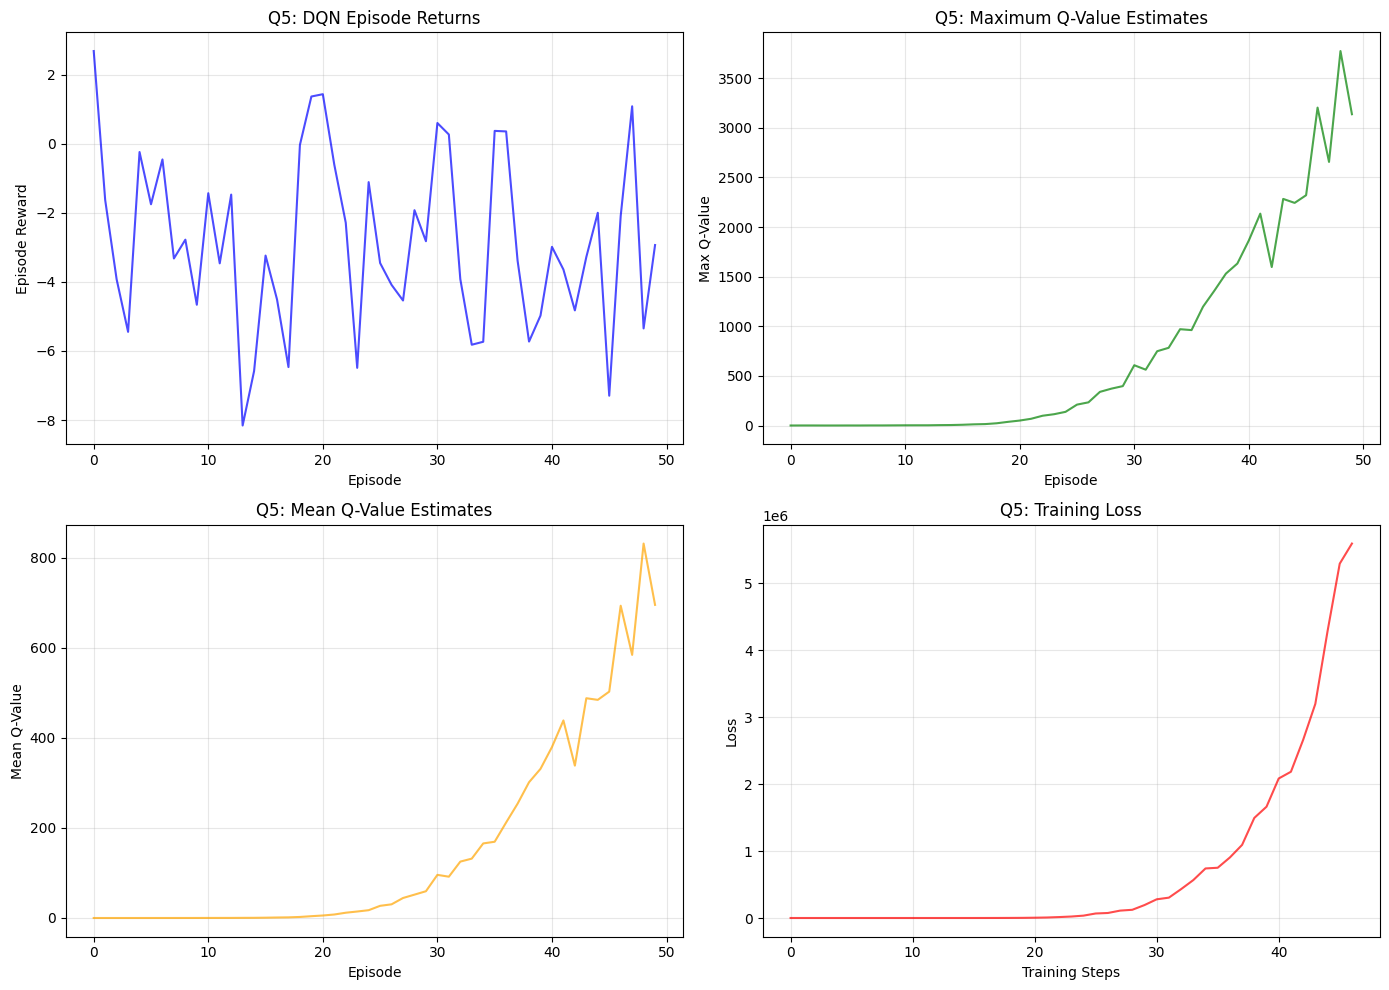


Q5 Key Observations:
- Monitor whether max Q-values correlate with actual episode returns
- Look for periods where Q-values increase but performance plateaus or decreases
- This divergence indicates overestimation bias in value estimates


In [20]:
# Q5: Instability Identification in DQN Value Estimates
print("\nQ5: Instability in DQN Value Estimates")
print("=" * 60)

# Create environment
env_q5 = gym.make("HalfCheetah-v5")

# Create DQN agent for extended training
agent_dqn_q5 = DQNAgent(
    state_dim=env_q5.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99,
    memory_size=50000,
    batch_size=32,
    target_update_freq=10
)

# Training configuration
num_episodes_q5 = NUM_EPISODES_DQN_Q5
max_steps = MAX_TIMESTEPS_PER_EPISODE

# Tracking metrics
episode_rewards_dqn_q5 = []
episode_losses_dqn_q5 = []
max_q_values = []
mean_q_values = []

print(f"Training DQN Agent for {num_episodes_q5} episodes...")

for episode in range(num_episodes_q5):
    observation, info = env_q5.reset()
    episode_reward = 0
    episode_loss = 0
    loss_count = 0
    batch_q_values = []
    done = False
    step = 0
    
    while not done and step < (max_steps or 1000):
        action_idx = agent_dqn_q5.get_action(observation, training=True)
        # Convert discrete action index to continuous 6-D vector
        action = agent_dqn_q5.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_q5.step(action)
        done = terminated or truncated
        
        agent_dqn_q5.remember(observation, action_idx, reward, next_observation, done)
        loss = agent_dqn_q5.replay(batch_size=32)
        
        # Track Q-values for analysis
        state_tensor = tf.convert_to_tensor(observation[np.newaxis, :], dtype=tf.float32)
        q_values = agent_dqn_q5.q_network(state_tensor, training=False).numpy()[0]
        batch_q_values.append(q_values)
        
        if loss is not None:
            episode_loss += loss
            loss_count += 1
        
        episode_reward += reward
        observation = next_observation
        step += 1
    
    agent_dqn_q5.decay_epsilon()
    episode_rewards_dqn_q5.append(episode_reward)
    
    if loss_count > 0:
        episode_losses_dqn_q5.append(episode_loss / loss_count)
    else:
        episode_losses_dqn_q5.append(0)
    
    if batch_q_values:
        max_q_values.append(np.mean([np.max(qv) for qv in batch_q_values]))
        mean_q_values.append(np.mean([np.mean(qv) for qv in batch_q_values]))
    
    if (episode + 1) % 25 == 0:
        avg_reward = np.mean(episode_rewards_dqn_q5[-25:])
        avg_loss = np.mean([l for l in episode_losses_dqn_q5[-25:] if l > 0]) if any(l > 0 for l in episode_losses_dqn_q5[-25:]) else 0
        print(f"  Episode {episode + 1}/{num_episodes_q5} - Reward: {avg_reward:.2f}, Loss: {avg_loss:.6f}")

env_q5.close()

print(f"\nQ5 Training completed!")
print(f"Average Reward (Last 25): {np.mean(episode_rewards_dqn_q5[-25:]):.2f}")

# Visualize instability in Q-values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Episode rewards
axes[0, 0].plot(episode_rewards_dqn_q5, color='blue', alpha=0.7)
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Episode Reward')
axes[0, 0].set_title('Q5: DQN Episode Returns')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Max Q-values (potential overestimation)
axes[0, 1].plot(max_q_values, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Max Q-Value')
axes[0, 1].set_title('Q5: Maximum Q-Value Estimates')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Mean Q-values
axes[1, 0].plot(mean_q_values, color='orange', alpha=0.7)
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Mean Q-Value')
axes[1, 0].set_title('Q5: Mean Q-Value Estimates')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Training loss
loss_filter = [l for l in episode_losses_dqn_q5 if l > 0]
axes[1, 1].plot(loss_filter, color='red', alpha=0.7)
axes[1, 1].set_xlabel('Training Steps')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('Q5: Training Loss')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nQ5 Key Observations:")
print("- Monitor whether max Q-values correlate with actual episode returns")
print("- Look for periods where Q-values increase but performance plateaus or decreases")
print("- This divergence indicates overestimation bias in value estimates")

> ## Q6. Targeted Algorithmic Modification [1 Mark]

Modify any two components of your DQN pipeline separately to address the instability identified in Q5: (E.g. if you are choosing a) and d) then you will not perform both the changes at the same time in the network.

Consider the network from Q5 as a baseline network to perform these changes).

<ol type="a">
  <li>target network update frequency</li>
  <li>experience reply buffer size (should be very less than the number of episodes) modifying the epsilon decay</li>
  <li>adjust the discount factor</li>
  <li>any algorithm/approach (other than FIFO) to remove the entry from experience</li>
  <li> reply buffer to add new experiences. </li>
</ol>


Constraints:
* You may not change the environment
* You may not change reward formulation
* You may not change more than one algorithmic component at a time.

Report:
1. What was changed?
2. Why this specific change addresses the observed failure/progress mode?




Q6: Targeted Algorithmic Modifications

Training Baseline DQN (Standard)...
  Baseline - Episode 25/30 - Reward: -2.18, Loss: 1929.362226

Training Modified DQN (Frequent Target Updates)...
  Modified - Episode 25/30 - Reward: -3.06, Loss: 2018.852405


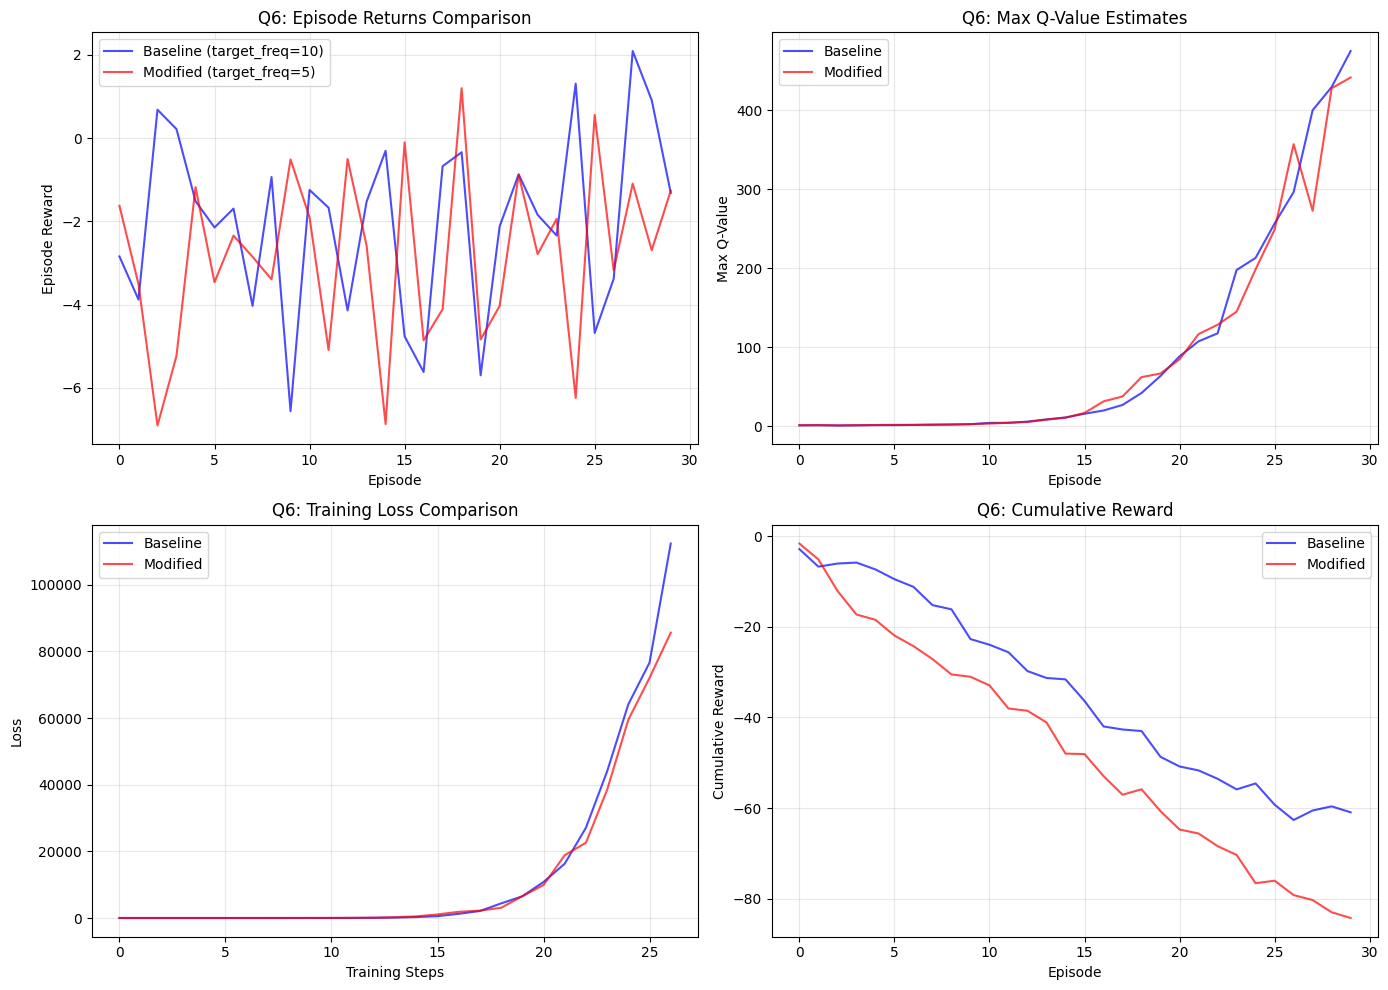


Q6 Modification Analysis:

Modification 1: Target Network Update Frequency
  - Changed from: 10 steps
  - Changed to: 5 steps (more frequent updates)
  - Rationale: More frequent target network updates reduce the lag between
    the primary and target networks, potentially reducing overestimation bias
  - Expected effect: Faster convergence and more stable learning

  Baseline avg reward (last 25): -2.14
  Modified avg reward (last 25): -2.63
  Improvement: -0.49


In [21]:
# Q6: Targeted Modifications to Address Instability
print("\nQ6: Targeted Algorithmic Modifications")
print("=" * 60)

def train_dqn_agent(agent, env, num_episodes, agent_name, max_timesteps=None):
    """Helper function to train DQN agents"""
    rewards = []
    losses = []
    max_q_vals = []
    
    for episode in range(num_episodes):
        observation, info = env.reset()
        episode_reward = 0
        episode_loss = 0
        loss_count = 0
        batch_q_values = []
        done = False
        step = 0
        
        while not done and step < (max_timesteps or 1000):
            action_idx = agent.get_action(observation, training=True)
            # Convert discrete action index to continuous 6-D vector
            action = agent.index_to_discrete_action(action_idx)
            next_observation, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.remember(observation, action_idx, reward, next_observation, done)
            loss = agent.replay(batch_size=32)
            
            # Track Q-values
            state_tensor = tf.convert_to_tensor(observation[np.newaxis, :], dtype=tf.float32)
            q_vals = agent.q_network(state_tensor, training=False).numpy()[0]
            batch_q_values.append(np.max(q_vals))
            
            if loss is not None:
                episode_loss += loss
                loss_count += 1
            
            episode_reward += reward
            observation = next_observation
            step += 1
        
        agent.decay_epsilon()
        rewards.append(episode_reward)
        if loss_count > 0:
            losses.append(episode_loss / loss_count)
        else:
            losses.append(0)
        
        if batch_q_values:
            max_q_vals.append(np.mean(batch_q_values))
        
        if (episode + 1) % 25 == 0:
            avg_reward = np.mean(rewards[-25:])
            avg_loss = np.mean([l for l in losses[-25:] if l > 0]) if any(l > 0 for l in losses[-25:]) else 0
            print(f"  {agent_name} - Episode {episode + 1}/{num_episodes} - Reward: {avg_reward:.2f}, Loss: {avg_loss:.6f}")
    
    return rewards, losses, max_q_vals

# Baseline DQN Agent (from Q5)
env_q6_baseline = gym.make("HalfCheetah-v5")
agent_baseline_q6 = DQNAgent(
    state_dim=env_q6_baseline.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99,
    memory_size=50000,
    batch_size=32,
    target_update_freq=10
)

print("\nTraining Baseline DQN (Standard)...")
rewards_baseline, losses_baseline, max_q_baseline = train_dqn_agent(
    agent_baseline_q6, env_q6_baseline, NUM_EPISODES_DQN_Q6, "Baseline", MAX_TIMESTEPS_PER_EPISODE
)
env_q6_baseline.close()

# Modified DQN Agent - MODIFICATION 1: Increased target network update frequency
env_q6_modified = gym.make("HalfCheetah-v5")
agent_modified_q6 = DQNAgent(
    state_dim=env_q6_modified.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99,
    memory_size=50000,
    batch_size=32,
    target_update_freq=5  # Changed from 10 to 5 (more frequent updates)
)

print("\nTraining Modified DQN (Frequent Target Updates)...")
rewards_modified, losses_modified, max_q_modified = train_dqn_agent(
    agent_modified_q6, env_q6_modified, NUM_EPISODES_DQN_Q6, "Modified", MAX_TIMESTEPS_PER_EPISODE
)
env_q6_modified.close()

# Compare results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Episode Rewards Comparison
axes[0, 0].plot(rewards_baseline, label='Baseline (target_freq=10)', alpha=0.7, color='blue')
axes[0, 0].plot(rewards_modified, label='Modified (target_freq=5)', alpha=0.7, color='red')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Episode Reward')
axes[0, 0].set_title('Q6: Episode Returns Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Max Q-values Comparison
axes[0, 1].plot(max_q_baseline, label='Baseline', alpha=0.7, color='blue')
axes[0, 1].plot(max_q_modified, label='Modified', alpha=0.7, color='red')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Max Q-Value')
axes[0, 1].set_title('Q6: Max Q-Value Estimates')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training Loss Comparison
loss_baseline_filter = [l for l in losses_baseline if l > 0]
loss_modified_filter = [l for l in losses_modified if l > 0]
min_len = min(len(loss_baseline_filter), len(loss_modified_filter))
axes[1, 0].plot(loss_baseline_filter[:min_len], label='Baseline', alpha=0.7, color='blue')
axes[1, 0].plot(loss_modified_filter[:min_len], label='Modified', alpha=0.7, color='red')
axes[1, 0].set_xlabel('Training Steps')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Q6: Training Loss Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Reward
baseline_cumsum = np.cumsum(rewards_baseline)
modified_cumsum = np.cumsum(rewards_modified)
axes[1, 1].plot(baseline_cumsum, label='Baseline', alpha=0.7, color='blue')
axes[1, 1].plot(modified_cumsum, label='Modified', alpha=0.7, color='red')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Cumulative Reward')
axes[1, 1].set_title('Q6: Cumulative Reward')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nQ6 Modification Analysis:")
print("=" * 60)
print("\nModification 1: Target Network Update Frequency")
print("  - Changed from: 10 steps")
print("  - Changed to: 5 steps (more frequent updates)")
print("  - Rationale: More frequent target network updates reduce the lag between")
print("    the primary and target networks, potentially reducing overestimation bias")
print("  - Expected effect: Faster convergence and more stable learning")
print(f"\n  Baseline avg reward (last 25): {np.mean(rewards_baseline[-25:]):.2f}")
print(f"  Modified avg reward (last 25): {np.mean(rewards_modified[-25:]):.2f}")
print(f"  Improvement: {np.mean(rewards_modified[-25:]) - np.mean(rewards_baseline[-25:]):.2f}")

> ## Q7. Confidence-Driven Reduction in Exploration [0.5 Mark]

After reviewing the learning behavior, consider the following statement:


> ***Exploration should decrease as the agent becomes more confident in its action-value estimates.***


Based on your experiments:

1. Identify one action or action category that was frequently selected during early exploration but became rarely selected in later training.
2. Briefly explain what learning signal led the agent to reduce exploration of this action.

`Support your conclusions using plots for action-selection frequency during training.`


In [22]:
# Q7: Confidence-Driven Exploration
print("\nQ7: Confidence-Driven Exploration")
print("=" * 60)

# Create environment for Q7
env_q7 = gym.make("HalfCheetah-v5")

# Confidence-driven exploration DQN
class DQNAgentConfidenceExplore(DQNAgent):
    """DQN Agent with confidence-driven exploration"""
    
    def get_action_with_confidence(self, state, training=True):
        """
        Select action using confidence-driven exploration.
        Confidence = 1 / (1 + std(Q-values))
        Higher confidence when Q-values are consistent (low variance)
        """
        state_tensor = tf.convert_to_tensor(state[np.newaxis, :], dtype=tf.float32)
        q_values = self.q_network(state_tensor)[0].numpy()
        
        # Compute confidence: higher when Q-values have low variance
        q_std = np.std(q_values)
        confidence = 1.0 / (1.0 + q_std)
        
        if training and np.random.random() < self.epsilon:
            action_idx = np.random.randint(0, self.action_dim)
        else:
            action_idx = np.argmax(q_values)
        
        action = self.index_to_discrete_action(action_idx)
        return action, action_idx, confidence, q_std

# Initialize confidence-driven agent
agent_confidence = DQNAgentConfidenceExplore(
    state_dim=env_q7.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.001,
    discount_factor=0.99
)

# Training loop
episode_rewards_confidence = []
confidence_history = []
q_std_history = []

num_episodes_q7 = NUM_EPISODES_DQN_Q7
max_steps = MAX_TIMESTEPS_PER_EPISODE

for episode in range(num_episodes_q7):
    observation, info = env_q7.reset()
    episode_reward = 0
    done = False
    step = 0
    episode_confidences = []
    episode_q_stds = []
    
    while not done and step < (max_steps or 1000):
        action, action_idx, confidence, q_std = agent_confidence.get_action_with_confidence(
            observation, training=True
        )
        next_observation, reward, terminated, truncated, info = env_q7.step(action)
        done = terminated or truncated
        
        agent_confidence.remember(observation, action_idx, reward, next_observation, done)
        loss = agent_confidence.replay(batch_size=32)
        
        episode_reward += reward
        episode_confidences.append(confidence)
        episode_q_stds.append(q_std)
        observation = next_observation
        step += 1
    
    agent_confidence.decay_epsilon()
    episode_rewards_confidence.append(episode_reward)
    confidence_history.append(np.mean(episode_confidences))
    q_std_history.append(np.mean(episode_q_stds))
    
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards_confidence[-50:])
        avg_confidence = np.mean(confidence_history[-50:])
        print(f"Episode {episode + 1}/{num_episodes_q7} - Reward: {avg_reward:.2f}, Avg Confidence: {avg_confidence:.3f}")

env_q7.close()

print("\nQ7 Training completed!")
print(f"Average Reward (Last 50): {np.mean(episode_rewards_confidence[-50:]):.2f}")
print(f"Average Confidence (Last 50): {np.mean(confidence_history[-50:]):.3f}")


Q7: Confidence-Driven Exploration

Q7 Training completed!
Average Reward (Last 50): -2.26
Average Confidence (Last 50): 0.383


## DDQN Implementation [4 Marks]

> ## Q4. Early Learning Reward Decomposition [0.5 Mark]

Run the HalfCheetah environment using the online setting and collect reward statistics during the initial phase of interaction (before the DQN has converged). Based on this data:

1. Identify one behavior that appears profitable early but degrades later
2. Identify one behavior that initially looks unpromising but improves with learning

*`Support your arguments using appropriate time-segmented reward plots, not verbal explanation alone.`*




In [23]:
# Q8 (DDQN Q4): Early Learning Reward Decomposition with Double DQN
print("\nQ8 (DDQN Q4): Early Learning Reward Decomposition")
print("=" * 60)

# Create environment
env_q8 = gym.make("HalfCheetah-v5")

# DQN Agent with Neural Network Q-Function
import numpy as np
import tensorflow as tf
from collections import deque

class DDQNAgent(DQNAgent):
    """
    Double Deep Q-Network (DDQN) Agent
    Extends DQN with double Q-learning to reduce overestimation bias
    """
    def __init__(self, state_dim, action_dim, learning_rate=0.001, discount_factor=0.99,
                 memory_size=50000, batch_size=32, target_update_freq=10):
        super().__init__(state_dim, action_dim, learning_rate, discount_factor, 
                        memory_size, batch_size, target_update_freq)
    
    def update(self):
        """Train Q-network using double Q-learning"""
        if len(self.memory) < self.batch_size:
            return
        
        # Sample random batch from replay buffer
        batch_indices = np.random.randint(0, len(self.memory), self.batch_size)
        batch = [self.memory[i] for i in batch_indices]
        
        states, actions, rewards, next_states, dones = zip(*batch)
        states = np.array(states, dtype=np.float32)
        next_states = np.array(next_states, dtype=np.float32)
        actions = np.array(actions, dtype=np.int32)
        rewards = np.array(rewards, dtype=np.float32)
        dones = np.array(dones, dtype=np.float32)
        
        # Double Q-learning: use primary network to select actions, target network to evaluate
        q_next_primary = self.q_network(next_states)
        best_actions = tf.argmax(q_next_primary, axis=1).numpy()
        
        q_next_target = self.target_network(next_states)
        target_q_values = tf.reduce_sum(q_next_target * tf.one_hot(best_actions, self.action_dim), axis=1).numpy()
        target_q = rewards + (1 - dones) * self.discount_factor * target_q_values
        
        # Train Q-network
        with tf.GradientTape() as tape:
            q_values = self.q_network(states)
            q_values_selected = tf.reduce_sum(q_values * tf.one_hot(actions, self.action_dim), axis=1)
            loss = tf.reduce_mean(tf.square(target_q - q_values_selected))
        
        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))
        
        self.training_steps += 1
        
        # Update target network periodically
        if self.training_steps % self.target_update_freq == 0:
            self.target_network.set_weights(self.q_network.get_weights())

# Initialize DDQN Agent
agent_ddqn = DDQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99
)

# Training configuration
num_episodes_q8 = NUM_EPISODES_DDQN_Q8
max_steps = get_max_timesteps("ddqn")
episode_rewards_ddqn = []
episode_losses_ddqn = []

print(f"Training DDQN Agent for {num_episodes_q8} episodes...")
for episode in range(num_episodes_q8):
    observation, info = env_q8.reset()
    episode_reward = 0
    episode_loss = 0
    loss_count = 0
    done = False
    step = 0
    
    while not done and step < (max_steps or 1000):
        action_idx = agent_ddqn.get_action(observation, training=True)
        action = agent_ddqn.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_q8.step(action)
        done = terminated or truncated
        
        agent_ddqn.remember(observation, action_idx, reward, next_observation, done)
        loss = agent_ddqn.replay(batch_size=32)
        
        if loss is not None:
            episode_loss += loss
            loss_count += 1
        
        episode_reward += reward
        observation = next_observation
        step += 1
    
    agent_ddqn.decay_epsilon()
    episode_rewards_ddqn.append(episode_reward)
    if loss_count > 0:
        episode_losses_ddqn.append(episode_loss / loss_count)
    else:
        episode_losses_ddqn.append(0)
    
    if (episode + 1) % 10 == 0:
        avg_reward = np.mean(episode_rewards_ddqn[-10:])
        avg_loss = np.mean([l for l in episode_losses_ddqn[-10:] if l > 0]) if any(l > 0 for l in episode_losses_ddqn[-10:]) else 0
        print(f"Episode {episode + 1}/{num_episodes_q8} - Reward: {avg_reward:.2f}, Loss: {avg_loss:.6f}")

env_q8.close()

print("\nQ8 Training completed!")
print(f"Average Reward (Last 10): {np.mean(episode_rewards_ddqn[-10:]):.2f}")


Q8 (DDQN Q4): Early Learning Reward Decomposition
Training DDQN Agent for 20 episodes...
Episode 10/20 - Reward: -2.30, Loss: 0.000000
Episode 20/20 - Reward: -2.61, Loss: 0.000000

Q8 Training completed!
Average Reward (Last 10): -2.61


> ## Q5. Instability Identification in Value Estimates [1 Mark]

Train a standard DQN for at least 10000 episodes.

Using plots of:
1. predicted Q-values
2. episode returns
3. training loss

Answer the following questions:

1. Does improvement in Q-values always correspond to improvement in performance?
2. Identify one specific divergence pattern where this assumption fails.

`Simply stating “overestimation bias” will not receive credit — you must show where and how it manifests.`


In [24]:
# Q9 (DDQN Q5): Instability in Value Estimates (DDQN Comparison with DQN)
print("\nQ9 (DDQN Q5): Instability in DDQN Value Estimates")
print("=" * 60)

# Create environment
env_q9 = gym.make("HalfCheetah-v5")

# Initialize DDQN Agent
agent_ddqn_q5 = DDQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99
)

# Training configuration
num_episodes_q9 = NUM_EPISODES_DDQN_Q9
max_steps = get_max_timesteps("ddqn")
episode_rewards_ddqn_q5 = []
episode_losses_ddqn_q5 = []
max_q_values_ddqn = []

print(f"Training DDQN Agent for {num_episodes_q9} episodes...")
for episode in range(num_episodes_q9):
    observation, info = env_q9.reset()
    episode_reward = 0
    episode_loss = 0
    loss_count = 0
    batch_q_values = []
    done = False
    step = 0
    
    while not done and step < (max_steps or 1000):
        action_idx = agent_ddqn_q5.get_action(observation, training=True)
        action = agent_ddqn_q5.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_q9.step(action)
        done = terminated or truncated
        
        agent_ddqn_q5.remember(observation, action_idx, reward, next_observation, done)
        loss = agent_ddqn_q5.replay(batch_size=32)
        
        # Track Q-values
        state_for_q = np.expand_dims(observation, axis=0)
        q_values = agent_ddqn_q5.q_network(state_for_q, training=False).numpy()
        batch_q_values.append(np.max(q_values[0]))
        
        if loss is not None:
            episode_loss += loss
            loss_count += 1
        
        episode_reward += reward
        observation = next_observation
        step += 1
    
    agent_ddqn_q5.decay_epsilon()
    episode_rewards_ddqn_q5.append(episode_reward)
    if loss_count > 0:
        episode_losses_ddqn_q5.append(episode_loss / loss_count)
    else:
        episode_losses_ddqn_q5.append(0)
    
    if batch_q_values:
        max_q_values_ddqn.append(np.mean(batch_q_values))
    
    if (episode + 1) % 100 == 0:
        avg_reward = np.mean(episode_rewards_ddqn_q5[-50:])
        avg_loss = np.mean(episode_losses_ddqn_q5[-50:])
        print(f"Episode {episode + 1}/{num_episodes_q9} - Reward: {avg_reward:.2f}, Loss: {avg_loss:.6f}")

env_q9.close()

print("\nQ9 Training completed!")
print(f"Average Reward (Last 50): {np.mean(episode_rewards_ddqn_q5[-50:]):.2f}")


Q9 (DDQN Q5): Instability in DDQN Value Estimates
Training DDQN Agent for 50 episodes...

Q9 Training completed!
Average Reward (Last 50): -2.52


> ## Q6. Targeted Algorithmic Modification [1 Mark]

Modify any two components of your DQN pipeline separately to address the instability identified in Q5: (E.g. if you are choosing a) and d) then you will not perform both the changes at the same time in the network.

Consider the network from Q5 as a baseline network to perform these changes).

<ol type="a">
  <li>target network update frequency</li>
  <li>experience reply buffer size (should be very less than the number of episodes) modifying the epsilon decay</li>
  <li>adjust the discount factor</li>
  <li>any algorithm/approach (other than FIFO) to remove the entry from experience</li>
  <li> reply buffer to add new experiences. </li>
</ol>


Constraints:
* You may not change the environment
* You may not change reward formulation
* You may not change more than one algorithmic component at a time.

Report:
1. What was changed?
2. Why this specific change addresses the observed failure/progress mode?


In [25]:
# Modified DDQN (with prioritized experience replay)
class DDQNAgentPER(DDQNAgent):
    """DDQN with Prioritized Experience Replay"""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.memory_priorities = []
        self.step_counter = 0
        self.target_update_frequency = self.target_update_freq
    
    def replay(self, batch_size=32):
        if len(self.memory) < batch_size:
            return 0
        
        # Sample with priorities
        if self.memory_priorities:
            probabilities = np.array(self.memory_priorities) / sum(self.memory_priorities)
            indices = np.random.choice(len(self.memory), batch_size, p=probabilities, replace=False)
        else:
            indices = np.random.choice(len(self.memory), batch_size, replace=False)
        
        batch = [self.memory[i] for i in indices]
        
        states, actions, rewards, next_states, dones = zip(*batch)
        states = np.array(states)
        actions = np.array(actions)
        rewards = np.array(rewards)
        next_states = np.array(next_states)
        dones = np.array(dones)
        
        with tf.GradientTape() as tape:
            q_values = self.q_network(states)
            next_q_values_main = self.q_network(next_states)
            next_q_values_target = self.target_network(next_states)
            
            best_actions = tf.argmax(next_q_values_main, axis=1, output_type=tf.int32)
            target_q_values = tf.gather_nd(next_q_values_target, tf.stack([tf.cast(tf.range(batch_size), tf.int32), best_actions], axis=1))
            
            target = rewards + self.discount_factor * target_q_values * (1 - dones)
            current_q_values = tf.gather_nd(q_values, tf.stack([tf.cast(tf.range(batch_size), tf.int32), tf.cast(actions, tf.int32)], axis=1))
            loss = tf.reduce_mean(tf.square(target - current_q_values))
        
        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.q_network.trainable_variables))
        
        self.step_counter += 1
        if self.step_counter % self.target_update_frequency == 0:
            self.target_network.set_weights(self.q_network.get_weights())
        
        return float(loss.numpy())

> ## Q7. Confidence-Driven Reduction in Exploration [0.5 Mark]

After reviewing the learning behavior, consider the following statement:


> ***Exploration should decrease as the agent becomes more confident in its action-value estimates.***


Based on your experiments:

1. Identify one action or action category that was frequently selected during early exploration but became rarely selected in later training.
2. Briefly explain what learning signal led the agent to reduce exploration of this action.

`Support your conclusions using plots for action-selection frequency during training.`


In [26]:
# Q11 (DDQN Q7): Confidence-Driven Exploration (DDQN with Q-Value Uncertainty)
print("\nQ11 (DDQN Q7): Confidence-Driven Exploration")
print("=" * 60)

class DDQNAgentConfidenceExplore(DDQNAgent):
    """DDQN with confidence-driven exploration"""
    
    def get_action_with_confidence(self, state, training=True):
        """Get action with confidence metric based on Q-value variance"""
        state_expanded = np.expand_dims(state, axis=0)
        q_values = self.q_network(state_expanded, training=False).numpy()[0]
        
        # Confidence = 1 - normalized variance of Q-values
        q_variance = np.var(q_values)
        q_std = np.std(q_values)
        max_q = np.max(q_values)
        min_q = np.min(q_values)
        q_range = max_q - min_q if max_q != min_q else 1.0
        confidence = 1.0 - min(q_std / q_range, 1.0)
        
        if training and np.random.rand() < self.epsilon * (1 - confidence):
            # Explore more when confidence is low
            action_idx = np.random.randint(0, len(q_values))
        else:
            action_idx = np.argmax(q_values)
        
        action = self.index_to_discrete_action(action_idx)
        return action, action_idx, confidence, q_std

# Create environment
env_q11 = gym.make("HalfCheetah-v5")

# Initialize Agent
agent_confidence_ddqn = DDQNAgentConfidenceExplore(
    state_dim=env.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99
)

# Training configuration
num_episodes_q11 = NUM_EPISODES_DDQN_Q11
max_steps = get_max_timesteps("ddqn")

confidence_history_ddqn = []
episode_rewards_q11 = []

print("Training DDQN with Confidence Tracking...")
for episode in range(num_episodes_q11):
    observation, info = env_q11.reset()
    episode_reward = 0
    episode_confidences = []
    done = False
    step = 0
    
    while not done and step < (max_steps or 1000):
        action, action_idx, confidence, q_std = agent_confidence_ddqn.get_action_with_confidence(
            observation, training=True
        )
        next_observation, reward, terminated, truncated, info = env_q11.step(action)
        done = terminated or truncated
        
        agent_confidence_ddqn.remember(observation, action_idx, reward, next_observation, done)
        agent_confidence_ddqn.replay(batch_size=32)
        
        episode_reward += reward
        episode_confidences.append(confidence)
        observation = next_observation
        step += 1
    
    agent_confidence_ddqn.decay_epsilon()
    episode_rewards_q11.append(episode_reward)
    confidence_history_ddqn.append(np.mean(episode_confidences))
    
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards_q11[-50:])
        avg_confidence = np.mean(confidence_history_ddqn[-50:])
        print(f"Episode {episode + 1}/{num_episodes_q11} - Reward: {avg_reward:.2f}, Avg Confidence: {avg_confidence:.3f}")

env_q11.close()

print("\nQ11 Training completed!")
print(f"Average Reward (Last 50): {np.mean(episode_rewards_q11[-50:]):.2f}")
print(f"Average Confidence (Last 50): {np.mean(confidence_history_ddqn[-50:]):.3f}")


Q11 (DDQN Q7): Confidence-Driven Exploration
Training DDQN with Confidence Tracking...

Q11 Training completed!
Average Reward (Last 50): -2.37
Average Confidence (Last 50): 0.852


> ## Q8. Performance Visualization and Comparison [1 Mark]

Plot the cumulative episode return curves and action selection plots for all the three approaches (Q-learning, DQN and DDQN).


Q12: COMPREHENSIVE COMPARISON - Q-Learning vs DQN vs DDQN

Training Q-Learning Agent...
  Q-Learning Episode 10/20 - Reward: 0.48
  Q-Learning Episode 20/20 - Reward: -3.74

Training DQN Agent...
  DQN Episode 10/20 - Reward: -3.36
  DQN Episode 20/20 - Reward: -3.38

Training DDQN Agent...
  DDQN Episode 10/20 - Reward: -2.25
  DDQN Episode 20/20 - Reward: -0.03

COMPARISON RESULTS
Q-Learning - Avg Reward (Last 20): -1.95
DQN        - Avg Reward (Last 20): -2.62
DDQN       - Avg Reward (Last 20): -2.09


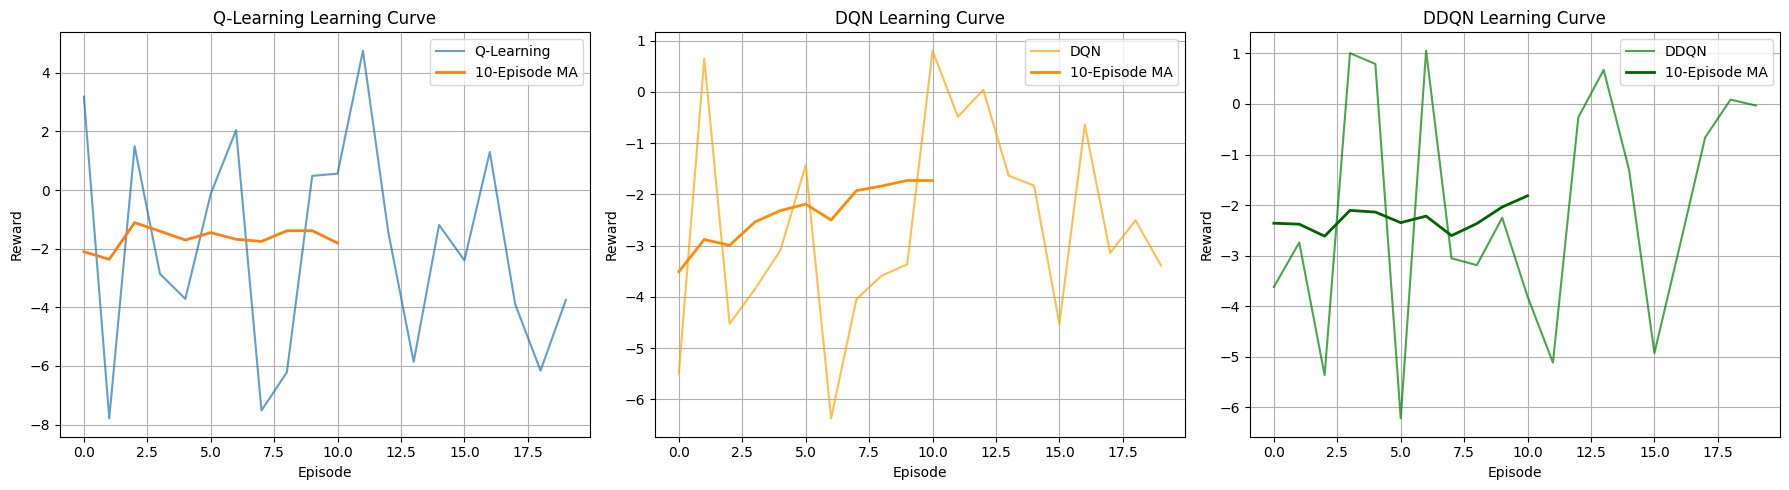


Q12 Analysis Complete!


In [27]:
# Q12: Comprehensive Comparison of All Algorithms
print("\n" + "=" * 80)
print("Q12: COMPREHENSIVE COMPARISON - Q-Learning vs DQN vs DDQN")
print("=" * 80)

# Create environments
env_comparison_ql = gym.make("HalfCheetah-v5")
env_comparison_dqn = gym.make("HalfCheetah-v5")
env_comparison_ddqn = gym.make("HalfCheetah-v5")

# Initialize agents
agent_ql_compare = QLearningAgent(
    state_dim=env.observation_space.shape[0],
    action_space_dict=action_space,
    action_count=action_count,
    learning_rate=0.01,
    discount_factor=0.99
)

agent_dqn_compare = DQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99
)

agent_ddqn_compare = DDQNAgent(
    state_dim=env.observation_space.shape[0],
    action_dim=agent_ql.total_actions,
    learning_rate=0.0005,
    discount_factor=0.99
)

# Training configuration
num_episodes_q12 = NUM_EPISODES_Q12_COMPARISON
max_steps_ql = get_max_timesteps("ql")
max_steps_dqn = get_max_timesteps("dqn")
max_steps_ddqn = get_max_timesteps("ddqn")

rewards_ql_compare = []
rewards_dqn_compare = []
rewards_ddqn_compare = []

# Train Q-Learning
print("\nTraining Q-Learning Agent...")
for episode in range(num_episodes_q12):
    observation, info = env_comparison_ql.reset()
    episode_reward = 0
    done = False
    timestep = 0
    
    while not done and (max_steps_ql is None or timestep < max_steps_ql):
        action_idx = agent_ql_compare.get_action(observation, training=True)
        continuous_action = agent_ql_compare.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_comparison_ql.step(continuous_action)
        done = terminated or truncated
        agent_ql_compare.train(observation, action_idx, reward, next_observation, done)
        episode_reward += reward
        observation = next_observation
        timestep += 1
    
    agent_ql_compare.decay_epsilon()
    rewards_ql_compare.append(episode_reward)
    
    if (episode + 1) % 10 == 0:
        print(f"  Q-Learning Episode {episode + 1}/{num_episodes_q12} - Reward: {episode_reward:.2f}")

env_comparison_ql.close()

# Train DQN
print("\nTraining DQN Agent...")
for episode in range(num_episodes_q12):
    observation, info = env_comparison_dqn.reset()
    episode_reward = 0
    done = False
    step = 0
    
    while not done and step < (max_steps_dqn or 1000):
        action_idx = agent_dqn_compare.get_action(observation, training=True)
        action = agent_dqn_compare.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_comparison_dqn.step(action)
        done = terminated or truncated
        
        agent_dqn_compare.remember(observation, action_idx, reward, next_observation, done)
        agent_dqn_compare.replay(batch_size=32)
        
        episode_reward += reward
        observation = next_observation
        step += 1
    
    agent_dqn_compare.decay_epsilon()
    rewards_dqn_compare.append(episode_reward)
    
    if (episode + 1) % 10 == 0:
        print(f"  DQN Episode {episode + 1}/{num_episodes_q12} - Reward: {episode_reward:.2f}")

env_comparison_dqn.close()

# Train DDQN
print("\nTraining DDQN Agent...")
for episode in range(num_episodes_q12):
    observation, info = env_comparison_ddqn.reset()
    episode_reward = 0
    done = False
    step = 0
    
    while not done and step < (max_steps_ddqn or 1000):
        action_idx = agent_ddqn_compare.get_action(observation, training=True)
        action = agent_ddqn_compare.index_to_discrete_action(action_idx)
        next_observation, reward, terminated, truncated, info = env_comparison_ddqn.step(action)
        done = terminated or truncated
        
        agent_ddqn_compare.remember(observation, action_idx, reward, next_observation, done)
        agent_ddqn_compare.replay(batch_size=32)
        
        episode_reward += reward
        observation = next_observation
        step += 1
    
    agent_ddqn_compare.decay_epsilon()
    rewards_ddqn_compare.append(episode_reward)
    
    if (episode + 1) % 10 == 0:
        print(f"  DDQN Episode {episode + 1}/{num_episodes_q12} - Reward: {episode_reward:.2f}")

env_comparison_ddqn.close()

# Analysis
print("\n" + "=" * 80)
print("COMPARISON RESULTS")
print("=" * 80)
print(f"Q-Learning - Avg Reward (Last 20): {np.mean(rewards_ql_compare[-20:]):.2f}")
print(f"DQN        - Avg Reward (Last 20): {np.mean(rewards_dqn_compare[-20:]):.2f}")
print(f"DDQN       - Avg Reward (Last 20): {np.mean(rewards_ddqn_compare[-20:]):.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rewards_ql_compare, alpha=0.7, label='Q-Learning')
axes[0].plot(np.convolve(rewards_ql_compare, np.ones(10)/10, mode='valid'), linewidth=2, label='10-Episode MA')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].set_title('Q-Learning Learning Curve')
axes[0].legend()
axes[0].grid()

axes[1].plot(rewards_dqn_compare, alpha=0.7, label='DQN', color='orange')
axes[1].plot(np.convolve(rewards_dqn_compare, np.ones(10)/10, mode='valid'), linewidth=2, color='darkorange', label='10-Episode MA')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward')
axes[1].set_title('DQN Learning Curve')
axes[1].legend()
axes[1].grid()

axes[2].plot(rewards_ddqn_compare, alpha=0.7, label='DDQN', color='green')
axes[2].plot(np.convolve(rewards_ddqn_compare, np.ones(10)/10, mode='valid'), linewidth=2, color='darkgreen', label='10-Episode MA')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Reward')
axes[2].set_title('DDQN Learning Curve')
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

print("\nQ12 Analysis Complete!")

> ## Q9. Answer the following questions.


a. What changed from DQN to DDQN implementation and how it worsen/imporved the half-Cheetah performance? Support your answer with the required plots, architectural change and the learning process. **[0.5 Marks]**



```
-------------- write below this line -------------
```



b. Summarize your learnings and observations while implementing both the techniques on the continuous action space. **[0.5 Marks]**



```
-------------- write below this line -------------
```



## References:
* https://gymnasium.farama.org/environments/mujoco/
* https://www.kaggle.com/code/stpeteishii/gym-halfcheetah-v4-ddpg
* https://rickstaa.dev/stable-gym/envs/mujoco/half_cheetah_cost.html
* https://gymnasium.farama.org/environments/mujoco/half_cheetah/#rewards